# Hierarchical Clustering en SKlearn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage



Definimos primero algunas funcones auxiliares que nos serviran para representar graficamente los grupos.

In [3]:
# Función para dibujar el círculo alrededor de cada cluster
def encircle(x, y, ax=None, **kw):
    if ax is None:
        ax = plt.gca()
    p = np.c_[x, y]
    mean = np.mean(p, axis=0)
    d = p - mean
    r = np.max(np.sqrt(d[:, 0]**2 + d[:, 1]**2))
    circ = plt.Circle(mean, radius=1.07 * r, **kw)
    ax.add_patch(circ)


#### Creamos un conjunto de datos sintético.

Conjunto formado por 5 clústeres. 

In [4]:
# Generación de datos
rng = default_rng(1513)
X1 = rng.normal(loc=2.0, scale=0.5, size=20).reshape((10, 2))
X2 = rng.normal(loc=-2.0, scale=0.5, size=20).reshape((10, 2))
X3 = rng.normal(loc=-5.0, scale=0.5, size=20).reshape((10, 2))
X4 = rng.normal(loc=5.0, scale=0.5, size=20).reshape((10, 2))
X5 = rng.normal(loc=0.0, scale=0.5, size=20).reshape((10, 2))
dummy_data = np.vstack([X1, X2, X3, X4, X5])
data = pd.DataFrame(dummy_data, columns=['x', 'y'])

# Normalización de los datos 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

### `AgglomerativeClustering` en `Sklearn`



* *n_clusters* (`int, default=2`). Define el número de clusters que se formarán al final.

Si no se especifica (None), hay que usar distance_threshold para definir el corte en el dendrograma.

* *metric* (`str, default='euclidean'`) Define cómo se mide la distancia entre puntos.
    * 'euclidean' (por defecto, distancia euclidiana clásica)
    * 'manhattan' (distancia Manhattan o city-block)
    * 'cosine' (distancia basada en el coseno del ángulo entre vectores)
    * 'precomputed' (para pasar una matriz de distancias personalizada)

Nota: *metric* funciona para todos los métodos de linkage excepto 'ward', que siempre usa 'euclidean'.

* *linkage* (`str, default='ward'`) Determina cómo se combinan los clusters en cada paso.
    * 'ward' → Minimiza la varianza dentro de los clusters (solo funciona con 'euclidean').
    * 'complete' → Usa la máxima distancia entre puntos de los clusters.
    * 'average' → Usa la distancia promedio entre todos los puntos de los clusters.
    * 'single' → Usa la mínima distancia entre puntos de los clusters.

In [5]:
# Configurar clustering jerárquico
n_clusters = 5
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage ='average' )

### Métodos de la clase `AgglomerativeClustering`.

* `fit(X)`: Entrena el modelo y agrupa los datos.

    * Calcula el dendrograma y asigna etiquetas de cluster a cada punto.
    * No devuelve nada, pero guarda la información en `labels_`.

* `fit_predict(X)`: Hace lo mismo que fit(X), pero devuelve directamente las etiquetas de los clusters.

* `get_params()`: Muestra los parámetros del modelo.

    * Devuelve un diccionario con los valores de `n_clusters`, `metric`, `linkage`, etc.

In [6]:
cluster_labels = clustering.fit_predict(data)

### Visualización de los resultados.

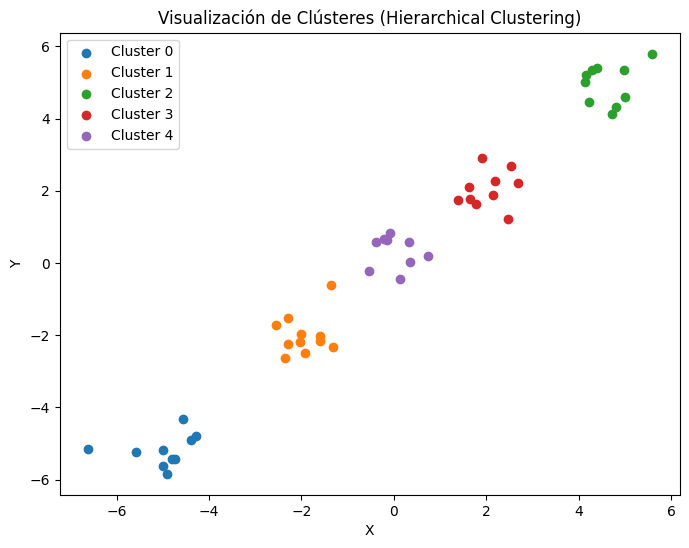

In [7]:
# Agregar etiquetas de clúster a los datos
data['cluster'] = cluster_labels

# Visualización de los clústeres
plt.figure(figsize=(8, 6))
for cluster in range(n_clusters):
    cluster_data = data[data['cluster'] == cluster]
    plt.scatter(cluster_data['x'], cluster_data['y'], label=f'Cluster {cluster}')
    
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Visualización de Clústeres (Hierarchical Clustering)")
plt.legend()
plt.show()

#### Ejemplo con diferentes valores para `n_clusters`

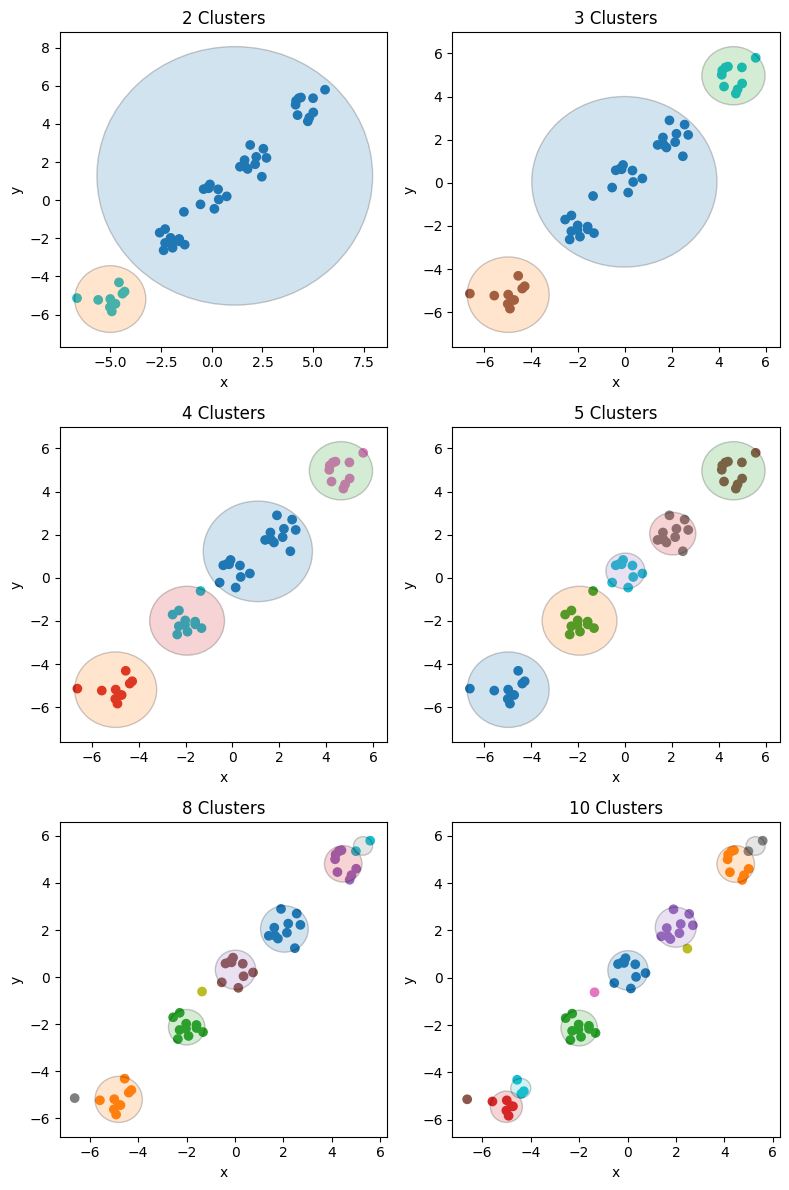

In [8]:

# Lista de clusters a visualizar
num_clusters_list = [2, 3, 4, 5, 8, 10]

# Graficamos los clusters obtenidos con AgglomerativeClustering
fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i, n_clusters in enumerate(num_clusters_list):
    fila = i//2
    columna = i%2
    ax = axes[fila, columna]

    clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='average')
    cluster_labels = clustering.fit_predict(X_scaled)  # 🔥 Etiquetas de cluster asignadas

    #Agregar etiquetas al DataFrame
    data["label"] = cluster_labels

    # Graficar los puntos con colores según el cluster
    scatter = ax.scatter(data['x'], data['y'], c=cluster_labels, cmap='tab10')

    # Dibujar círculos alrededor de los clusters
    colors = plt.get_cmap("tab10").colors  # Lista de colores
    for label in range(n_clusters):
        cluster_data = data[data["label"] == label]
        encircle(cluster_data.x, cluster_data.y, ax=ax, ec="k", fc=colors[label], alpha=0.2)

    # Configurar la gráfica
    ax.set_title(f"{n_clusters} Clusters")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()



### Dendrogramas en Hierarchical Clustering.

Un dendrograma es una representación visual del proceso de agrupamiento jerárquico en clustering. Se usa para entender cómo se fusionan los puntos en distintos niveles.

Se usan dos funciones del módulo `scipy.cluster.hierarchy`

* `linkage_matrix = linkage(X, method='ward', metric='euclidean')` → Calcula la jerarquía de clustering
Genera una matriz que indica cómo se agrupan los puntos paso a paso.
Cada fila representa una fusión entre dos clusters 
    * `X`: Conjunto de datos a la entrada del modelo.  En nuestro caso *X_scaled*
    * `method`: El tipo de *linkage*
    * `metric`: La distancia elegida.

* `dendrogram(linkage_matrix,truncate_mode='lastp', p=10)` → Dibuja el dendrograma.
REcibe:
    * `linkage_matrix`: La matriz de enlaces generada por `linkage`
    * `truncate_mode`: Regula la información (niveles) que muestra el dendrograma:
        * `'None'`: Por defecto. Muestra todas las fusiones, desde los puntos individuales hasta el cluster final.
        * `'lastp'`: Muestra solo las últimas `p` fusiones, en lugar de todas. 
        * `'level'`: Muestra solo las fusiones hasta un cierto nivel en el árbol. `p` indica la profundidad.


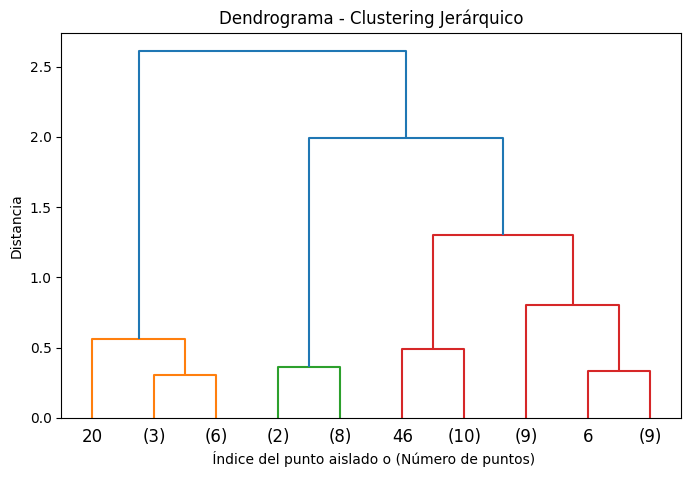

In [9]:
# Graficamos el dendrograma para referencia
plt.figure(figsize=(8, 5))
linkage_matrix = linkage(X_scaled, method='average')
dendrogram(linkage_matrix,truncate_mode='lastp', p=10)
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel(" Índice del punto aislado o (Número de puntos)")
plt.ylabel("Distancia")
plt.show()

### Funciones auxiliares para ver el comportamiento del agrupamiento.

En `sklearn`, no hay un método directo para calcular el **WCSS** (*Within-Cluster Sum of Squares*, suma de los cuadrados dentro de los clusters) en `AgglomerativeClustering`.

Pero podemos calcularla de forma manual.

In [10]:
def compute_wcss(X, labels):
    wcss = 0
    for cluster in np.unique(labels):
        cluster_points = X[labels == cluster]  # Extraer puntos del cluster
        centroid = np.mean(cluster_points, axis=0)  # Calcular centroide
        wcss += np.sum((cluster_points - centroid) ** 2)  # Suma de distancias cuadradas
    return wcss

Lo evaluamos en nuestro ejemplo de 5 grupos.

In [11]:
# Configurar clustering jerárquico
n_clusters = 5
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage ='average' )
cluster_labels = clustering.fit_predict(data)

wcss_value = compute_wcss(X_scaled, cluster_labels)
print(f"WCSS: {wcss_value:.2f}")



WCSS: 10.50


#### Cómo usar WCSS para evaluar el modelo
El WCSS es útil para elegir el mejor número de clusters. Una estrategia común es el método del codo (*Elbow Method*):

* El "codo" en la gráfica indica el número óptimo de clusters.
* Si el WCSS deja de disminuir significativamente, hemos encontrado el mejor

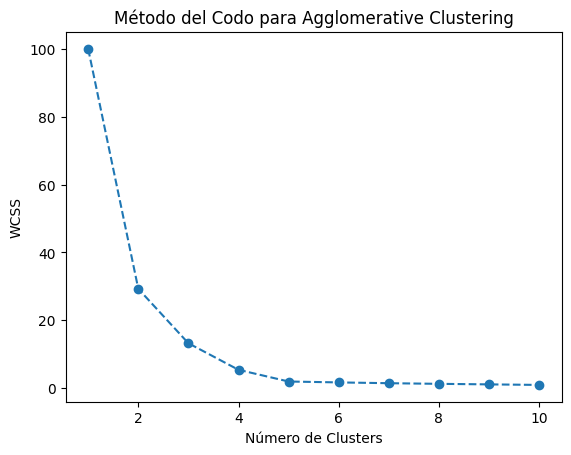

In [12]:
wcss_values = []

# Probar diferentes números de clusters
for k in range(1, 11):
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = clustering.fit_predict(X_scaled)
    wcss_values.append(compute_wcss(X_scaled, labels))

# Graficar el método del codo
plt.plot(range(1, 11), wcss_values, marker='o', linestyle='--')
plt.xlabel("Número de Clusters")
plt.ylabel("WCSS")
plt.title("Método del Codo para Agglomerative Clustering")
plt.show()